In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/Dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [2]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             obje

In [3]:
df = pd.read_csv("C:\\Restaurant-Analytics-Insights\\data\\Dataset.csv")

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant ID,9551.0,NaN,NaN,NaN,9051128.349178,8791521.282104,53.0,301962.5,6004089.0,18352291.5,18500652.0
Restaurant Name,9551,7446,Cafe Coffee Day,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Code,9551.0,NaN,NaN,NaN,18.365616,56.750546,1.0,1.0,1.0,1.0,216.0
City,9551,141,New Delhi,5473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,9551,8918,"Dilli Haat, INA, New Delhi",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality,9551,1208,Connaught Place,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Locality Verbose,9551,1265,"Connaught Place, New Delhi",122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,9551.0,NaN,NaN,NaN,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,NaN,NaN,NaN,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.97698
Cuisines,9542,1825,North Indian,936,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
columns_to_check = [
    "City",
    "Cuisines",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Rating text"
]

for col in columns_to_check:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- City ---
City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
Bhubaneshwar        21
Amritsar            21
Ahmedabad           21
Lucknow             21
Guwahati            21
Ludhiana            20
Rest of Hawaii      20
Kochi               20
Kolkata             20
Pocatello           20
Name: count, dtype: int64

--- Cuisines ---
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Name: count, 

In [6]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

print("Missing Cuisines:", df["Cuisines"].isna().sum())

Missing Cuisines: 0


In [7]:
numeric_columns = [
    "Longitude",
    "Latitude",
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Longitude,9551.0,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.976980
Average Cost for two,9551.0,1199.210763,16121.183073,0.000000,250.000000,400.000000,700.000000,800000.000000
Price range,9551.0,1.804837,0.905609,1.000000,1.000000,2.000000,2.000000,4.000000
Aggregate rating,9551.0,2.666370,1.516378,0.000000,2.500000,3.200000,3.700000,4.900000
Votes,9551.0,156.909748,430.169145,0.000000,5.000000,31.000000,131.000000,10934.000000


In [8]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Longitude,9551.0,64.126574,41.467058,-157.948486,77.081343,77.191964,77.282006,174.832089
Latitude,9551.0,25.854381,11.007935,-41.330428,28.478713,28.570469,28.642758,55.976980
Average Cost for two,9551.0,1199.210763,16121.183073,0.000000,250.000000,400.000000,700.000000,800000.000000
Price range,9551.0,1.804837,0.905609,1.000000,1.000000,2.000000,2.000000,4.000000
Aggregate rating,9551.0,2.666370,1.516378,0.000000,2.500000,3.200000,3.700000,4.900000
Votes,9551.0,156.909748,430.169145,0.000000,5.000000,31.000000,131.000000,10934.000000


In [9]:
df.nlargest(10, "Average Cost for two")[
    [
        "Restaurant Name",
        "City",
        "Currency",
        "Average Cost for two",
        "Price range",
        "Aggregate rating"
    ]
]

,Restaurant Name,City,Currency,Average Cost for two,Price range,Aggregate rating
9283,Skye,Jakarta,Indonesian Rupiah(IDR),800000,3,4.1
9284,Satoo - Hotel Shangri-La,Jakarta,Indonesian Rupiah(IDR),800000,3,4.6
9287,Sushi Masa,Jakarta,Indonesian Rupiah(IDR),500000,3,4.9
9289,3 Wise Monkeys,Jakarta,Indonesian Rupiah(IDR),450000,3,4.2
9294,Avec Moi Restaurant and Bar,Jakarta,Indonesian Rupiah(IDR),350000,3,4.3
9288,Lucky Cat Coffee & Kitchen,Jakarta,Indonesian Rupiah(IDR),300000,3,4.3
9295,Onokabe,Tangerang,Indonesian Rupiah(IDR),300000,3,3.7
9278,Lemongrass,Bogor,Indonesian Rupiah(IDR),250000,3,4.0
9285,MONKS,Jakarta,Indonesian Rupiah(IDR),250000,3,4.2
9279,Talaga Sampireun,Jakarta,Indonesian Rupiah(IDR),200000,3,4.9


In [10]:
country_currency = (
    df.groupby(["Country Code", "Currency"])
      .size()
      .reset_index(name="Restaurant Count")
      .sort_values("Restaurant Count", ascending=False)
)

country_currency

,Country Code,Currency,Restaurant Count
0,1,Indian Rupees(Rs.),8652
14,216,Dollar($),434
13,215,Pounds(��),80
2,30,Brazilian Real(R$),60
9,189,Rand(R),60
12,214,Emirati Diram(AED),60
5,148,NewZealand($),40
11,208,Turkish Lira(TL),34
1,14,Dollar($),24
6,162,Botswana Pula(P),22


In [11]:
df["Country Code"].value_counts()

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64

In [12]:
country_currency = (
    df.groupby(["Country Code", "Currency"])
      .size()
      .reset_index(name="Restaurant Count")
      .sort_values("Restaurant Count", ascending=False)
)

country_currency

,Country Code,Currency,Restaurant Count
0,1,Indian Rupees(Rs.),8652
14,216,Dollar($),434
13,215,Pounds(��),80
2,30,Brazilian Real(R$),60
9,189,Rand(R),60
12,214,Emirati Diram(AED),60
5,148,NewZealand($),40
11,208,Turkish Lira(TL),34
1,14,Dollar($),24
6,162,Botswana Pula(P),22


In [13]:
df["Country Code"].value_counts()

Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64

In [14]:
zero_counts = {
    "Average Cost for two": (df["Average Cost for two"] == 0).sum(),
    "Price range": (df["Price range"] == 0).sum(),
    "Aggregate rating": (df["Aggregate rating"] == 0).sum(),
    "Votes": (df["Votes"] == 0).sum()
}

pd.Series(zero_counts).sort_values(ascending=False)

Aggregate rating        2148
Votes                   1094
Average Cost for two      18
Price range                0
dtype: int64

In [15]:
zero_rating = df[df["Aggregate rating"] == 0]

zero_rating[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Average Cost for two",
        "Price range",
        "Aggregate rating",
        "Rating text",
        "Votes"
    ]
].head(20)

,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Aggregate rating,Rating text,Votes
30,Sandubas Caf��,Bras�_lia,"Brazilian, Cafe",30,1,0.0,Not rated,2
58,Quiosque Chopp Brahma,Rio de Janeiro,"Bar Food, Brazilian",70,3,0.0,Not rated,1
69,Cantinho da Gula,S��o Paulo,Brazilian,55,2,0.0,Not rated,0
77,Divino Fog��o,S��o Paulo,"Brazilian, Mineira",65,3,0.0,Not rated,2
78,Super Grill,S��o Paulo,Brazilian,50,2,0.0,Not rated,2
238,Frick's Tap,Davenport,"American, Bar Food, BBQ",25,2,0.0,Not rated,2
239,Los Agaves,Davenport,Mexican,25,2,0.0,Not rated,3
412,Nosh Mahal,Pocatello,"Indian, Persian",25,2,0.0,Not rated,1
871,Aggarwal Sweet Corner,Faridabad,Mithai,100,1,0.0,Not rated,1
872,Kashyap Vaishno Dhaba,Faridabad,North Indian,100,1,0.0,Not rated,3


In [16]:
df_rated = df[df["Aggregate rating"] > 0].copy()

print("Original dataset:", df.shape)
print("Rated restaurants:", df_rated.shape)
print("Unrated restaurants:", df.shape[0] - df_rated.shape[0])

Original dataset: (9551, 21)
Rated restaurants: (7403, 21)
Unrated restaurants: 2148


In [17]:
df[df["Average Cost for two"] == 0][
    [
        "Restaurant Name",
        "City",
        "Country Code",
        "Currency",
        "Average Cost for two",
        "Price range",
        "Aggregate rating"
    ]
]

,Restaurant Name,City,Country Code,Currency,Average Cost for two,Price range,Aggregate rating
84,Cookie Shoppe,Albany,216,Dollar($),0,1,3.4
85,El Vaquero Mexican Restaurant,Albany,216,Dollar($),0,1,3.4
87,Pearly's Famous Country Cookng,Albany,216,Dollar($),0,1,3.4
201,Deorio's,Columbus,216,Dollar($),0,1,4.0
240,Azteca,Davenport,216,Dollar($),0,1,4.3
277,Happy Joe's Pizza & Ice Cream,Dubuque,216,Dollar($),0,1,3.5
346,HI Lite Bar & Lounge,Miller,216,Dollar($),0,1,3.4
397,Royal Hotel,Pocatello,216,Dollar($),0,1,3.6
407,Senor Iguanas,Pocatello,216,Dollar($),0,1,3.6
634,The Latitude - Radisson Blu,Agra,1,Indian Rupees(Rs.),0,1,3.9


In [18]:
df_clean = df.copy()

In [19]:
df_clean["Average Cost for two"] = df_clean["Average Cost for two"].replace(0, np.nan)

df_rated = df_clean[df_clean["Aggregate rating"] > 0].copy()

In [20]:
print("Original dataset:", df.shape)
print("Clean dataset:", df_clean.shape)
print("Rated restaurants:", df_rated.shape)
print("Missing cuisines:", df_clean["Cuisines"].isna().sum())
print("Missing costs:", df_clean["Average Cost for two"].isna().sum())

Original dataset: (9551, 21)
Clean dataset: (9551, 21)
Rated restaurants: (7403, 21)
Missing cuisines: 0
Missing costs: 18


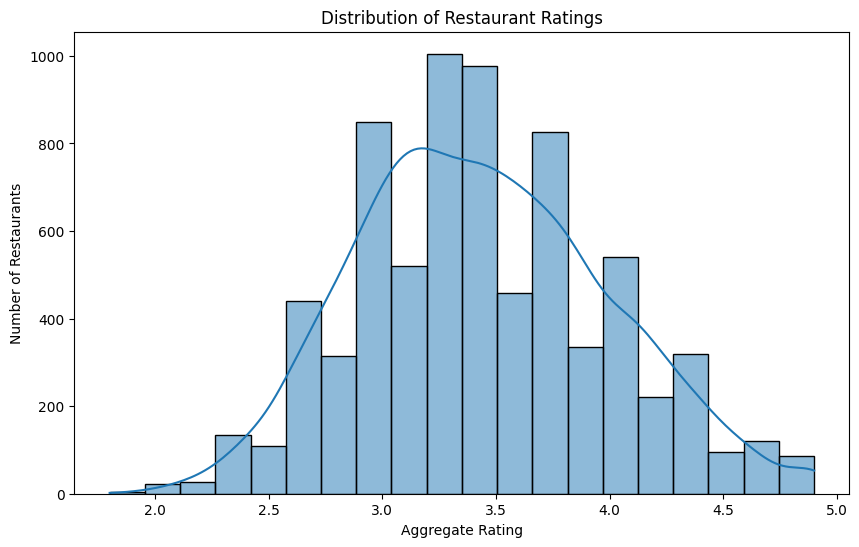

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_rated["Aggregate rating"], 
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

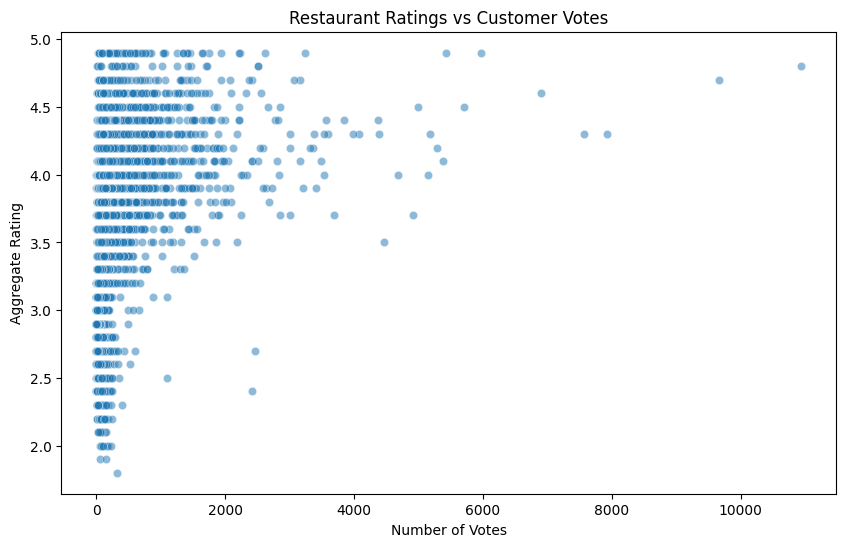

In [22]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_rated,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.title("Restaurant Ratings vs Customer Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Aggregate Rating")

plt.show()

In [23]:

correlation = df_rated["Votes"].corr(
    df_rated["Aggregate rating"]
)

print(f"Correlation between Votes and Rating: {correlation:.3f}")

Correlation between Votes and Rating: 0.409


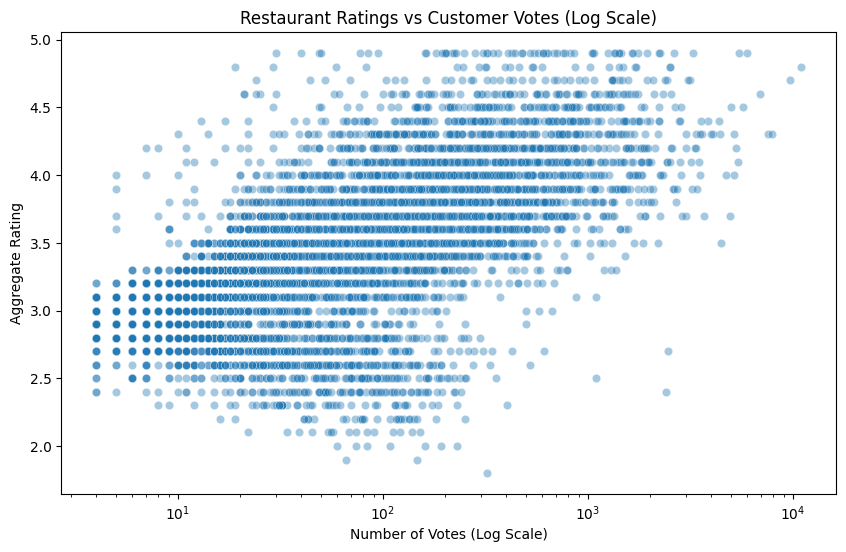

In [24]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_rated,
    x="Votes",
    y="Aggregate rating",
    alpha=0.4
)

plt.xscale("log")

plt.title("Restaurant Ratings vs Customer Votes (Log Scale)")
plt.xlabel("Number of Votes (Log Scale)")
plt.ylabel("Aggregate Rating")

plt.show()

In [25]:
df_rated["Log Votes"] = np.log1p(df_rated["Votes"])

df_rated[["Restaurant Name", "Aggregate rating", "Votes", "Log Votes"]].head()

,Restaurant Name,Aggregate rating,Votes,Log Votes
0,Le Petit Souffle,4.8,314,5.752573
1,Izakaya Kikufuji,4.5,591,6.383507
2,Heat - Edsa Shangri-La,4.4,270,5.602119
3,Ooma,4.9,365,5.902633
4,Sambo Kojin,4.8,229,5.438079


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_rated[["Rating Score", "Popularity Score"]] = scaler.fit_transform(
    df_rated[["Aggregate rating", "Log Votes"]]
)

df_rated[
    [
        "Restaurant Name",
        "Aggregate rating",
        "Votes",
        "Rating Score",
        "Popularity Score"
    ]
].head()

,Restaurant Name,Aggregate rating,Votes,Rating Score,Popularity Score
0,Le Petit Souffle,4.8,314,0.967742,0.538749
1,Izakaya Kikufuji,4.5,591,0.870968,0.620792
2,Heat - Edsa Shangri-La,4.4,270,0.838710,0.519185
3,Ooma,4.9,365,1.000000,0.558262
4,Sambo Kojin,4.8,229,0.967742,0.497854


In [27]:
df_rated["Performance Score"] = (
    0.60 * df_rated["Rating Score"] +
    0.40 * df_rated["Popularity Score"]
)

In [28]:
top_performers = (
    df_rated[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score"
        ]
    ]
    .sort_values("Performance Score", ascending=False)
    .head(15)
)

top_performers

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
728,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645
2414,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494
2307,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637
735,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885
2495,Mirchi And Mime,Mumbai,"North Indian, South Indian, Mughlai",4.9,3244,0.936811
3013,Naturals Ice Cream,New Delhi,Ice Cream,4.9,2620,0.925703
739,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046
374,McGuire's Irish Pub & Brewery,Pensacola,"Burger, Bar Food, Steak",4.9,2238,0.917509
9296,Talaga Sampireun,Tangerang,"Sunda, Indonesian",4.9,2212,0.916902
3601,Indian Accent - The Manor,New Delhi,Modern Indian,4.9,1934,0.909920


In [29]:
top_cities = (
    df_clean["City"]
    .value_counts()
    .head(15)
)

top_cities

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
Bhubaneshwar        21
Amritsar            21
Ahmedabad           21
Lucknow             21
Guwahati            21
Ludhiana            20
Rest of Hawaii      20
Kochi               20
Kolkata             20
Pocatello           20
Name: count, dtype: int64

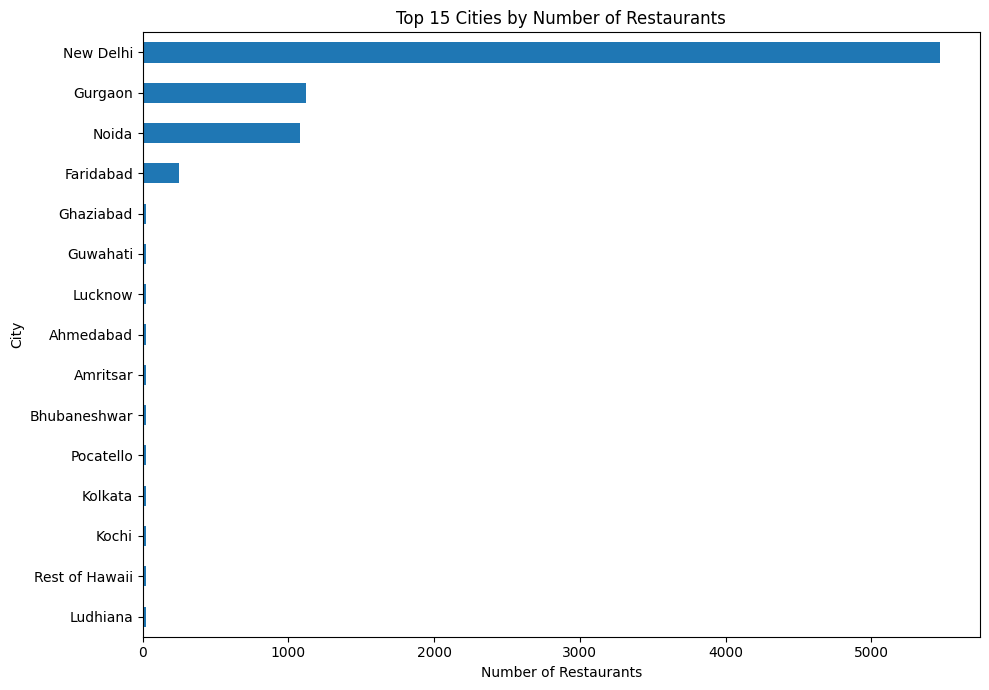

In [30]:
plt.figure(figsize=(10, 7))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [31]:
city_performance = (
    df_rated
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

city_performance = city_performance.sort_values(
    "Restaurant_Count",
    ascending=False
)

city_performance.head(20)

,City,Restaurant_Count,Average_Rating,Total_Votes
88,New Delhi,4048,3.297381,627090
50,Gurgaon,890,3.330674,131978
89,Noida,696,3.159626,73148
43,Faridabad,151,3.103311,6406
48,Ghaziabad,23,3.100000,2365
5,Amritsar,21,3.685714,3665
17,Bhubaneshwar,21,3.980952,4243
51,Guwahati,21,4.190476,4964
2,Ahmedabad,21,4.161905,12266
69,Lucknow,21,4.195238,9130


In [32]:
city_performance_filtered = city_performance[
    city_performance["Restaurant_Count"] >= 30
].copy()

city_performance_filtered = city_performance_filtered.sort_values(
    "Average_Rating",
    ascending=False
)

city_performance_filtered.head(15)

,City,Restaurant_Count,Average_Rating,Total_Votes
50,Gurgaon,890,3.330674,131978
88,New Delhi,4048,3.297381,627090
89,Noida,696,3.159626,73148
43,Faridabad,151,3.103311,6406


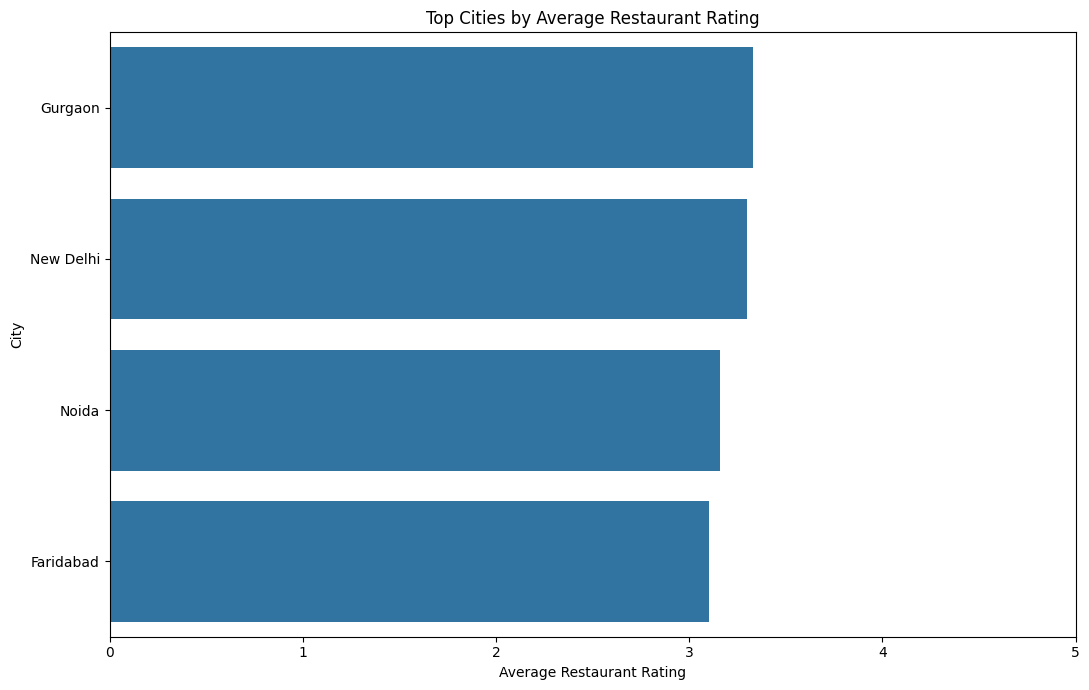

In [33]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=city_performance_filtered.head(15),
    x="Average_Rating",
    y="City"
)

plt.title(
    "Top Cities by Average Restaurant Rating"
)

plt.xlabel("Average Restaurant Rating")
plt.ylabel("City")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [34]:

cuisine_series = (
    df_clean["Cuisines"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_cuisines = cuisine_series.value_counts().head(20)

top_cuisines

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Thai             234
Asian            233
Beverages        229
Ice Cream        226
Mexican          181
Name: count, dtype: int64

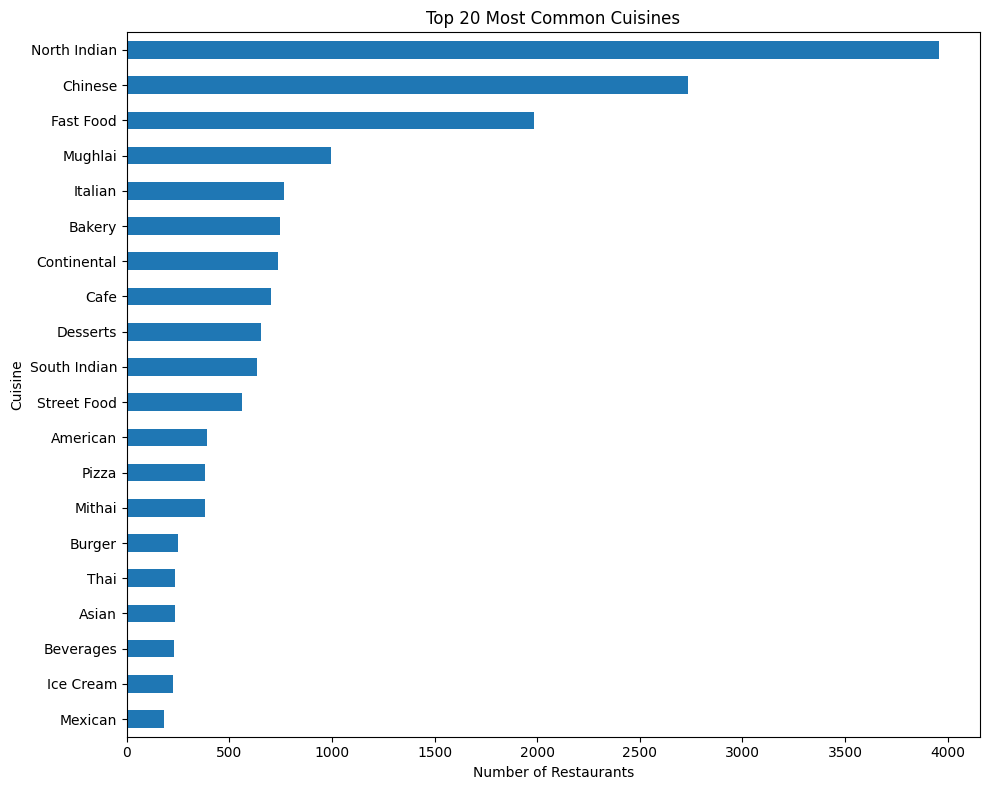

In [35]:
plt.figure(figsize=(10, 8))

top_cuisines.sort_values().plot(kind="barh")

plt.title("Top 20 Most Common Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

In [36]:
cuisine_data = df_rated[
    ["Cuisines", "Aggregate rating", "Votes"]
].copy()

cuisine_data["Cuisine"] = (
    cuisine_data["Cuisines"]
    .str.split(", ")
)

cuisine_data = cuisine_data.explode("Cuisine")

cuisine_performance = (
    cuisine_data
    .groupby("Cuisine")
    .agg(
        Restaurant_Count=("Aggregate rating", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

# Only consider cuisines with at least 30 restaurants
cuisine_performance_filtered = (
    cuisine_performance[
        cuisine_performance["Restaurant_Count"] >= 30
    ]
    .sort_values("Average_Rating", ascending=False)
)

cuisine_performance_filtered.head(15)

,Cuisine,Restaurant_Count,Average_Rating,Total_Votes
64,Indian,66,4.156061,22391
14,Bar Food,37,4.145946,15681
114,Sandwich,53,4.066038,23500
12,BBQ,32,4.025000,9645
86,Mediterranean,110,4.020000,80532
126,Steak,62,3.985484,25677
129,Sushi,75,3.973333,20582
21,Breakfast,41,3.965854,16097
47,European,146,3.964384,103305
116,Seafood,171,3.929825,74254


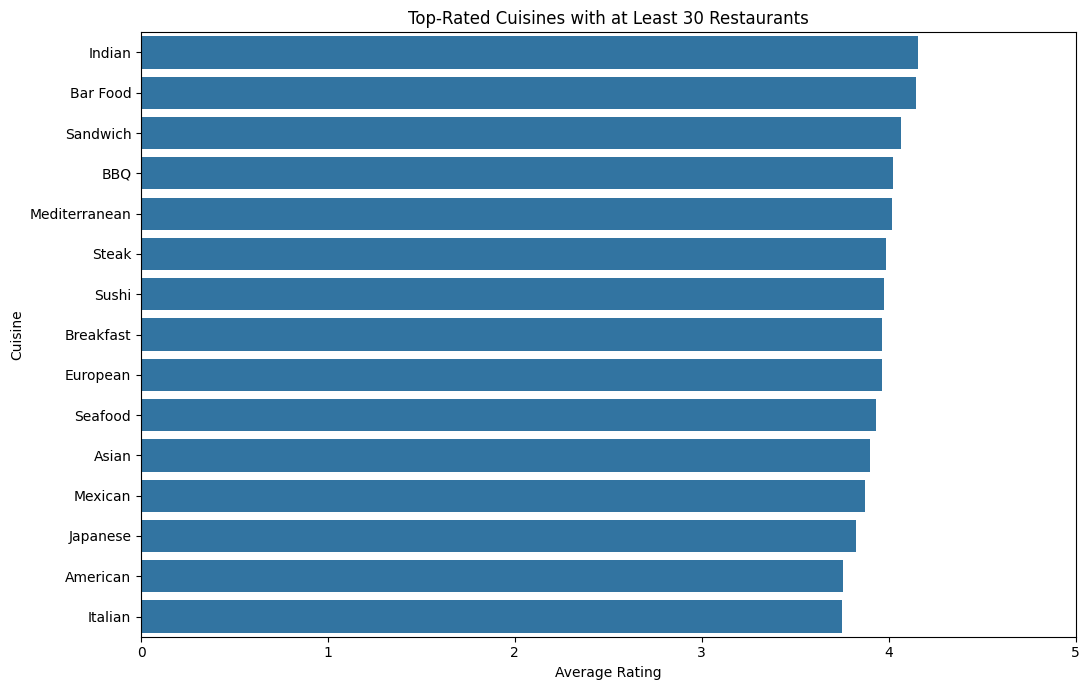

In [37]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=cuisine_performance_filtered.head(15),
    x="Average_Rating",
    y="Cuisine"
)

plt.title(
    "Top-Rated Cuisines with at Least 30 Restaurants"
)

plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [38]:
price_rating = (
    df_rated
    .groupby("Price range")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

price_rating

,Price range,Restaurant_Count,Average_Rating,Average_Votes
0,1,2744,3.238885,71.713192
1,2,2711,3.377167,169.347473
2,3,1373,3.777276,455.142025
3,4,575,3.890957,375.624348


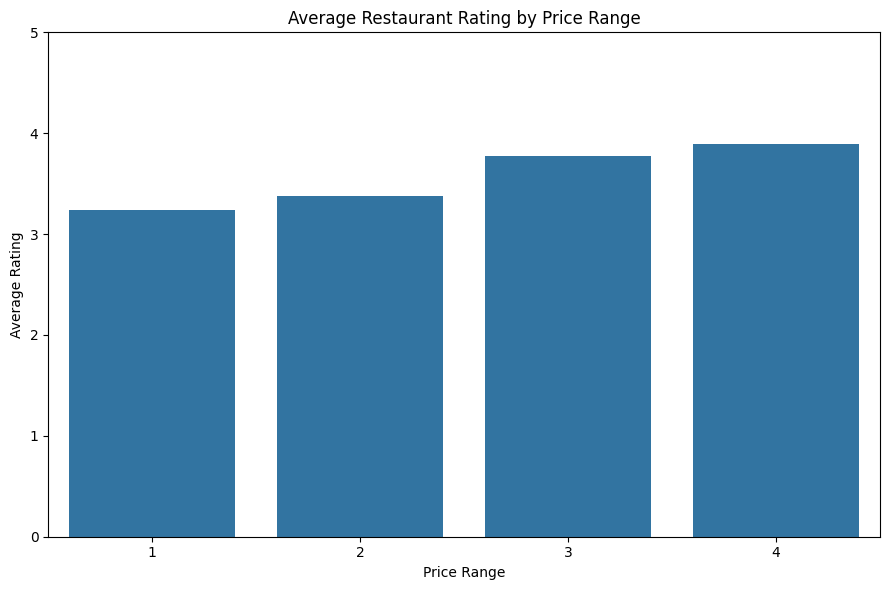

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=price_rating,
    x="Price range",
    y="Average_Rating"
)

plt.title("Average Restaurant Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

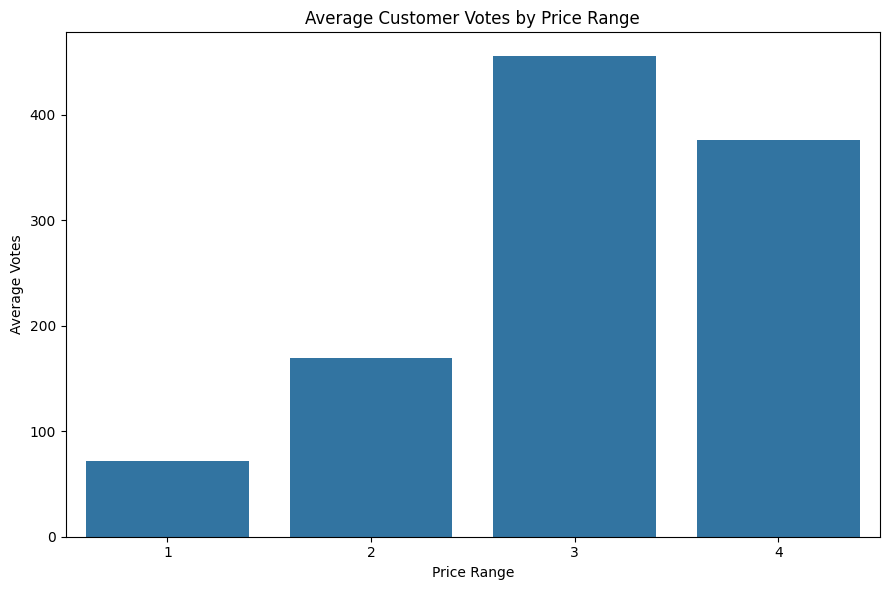

In [40]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=price_rating,
    x="Price range",
    y="Average_Votes"
)

plt.title("Average Customer Votes by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [41]:

digital_rating = (
    df_rated
    .groupby(
        ["Has Online delivery", "Has Table booking"]
    )
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

digital_rating

,Has Online delivery,Has Table booking,Restaurant_Count,Average_Rating,Average_Votes
0,No,No,4370,3.451259,177.683982
1,No,Yes,678,3.571681,298.718289
2,Yes,No,1922,3.329188,162.042144
3,Yes,Yes,433,3.612471,476.491917


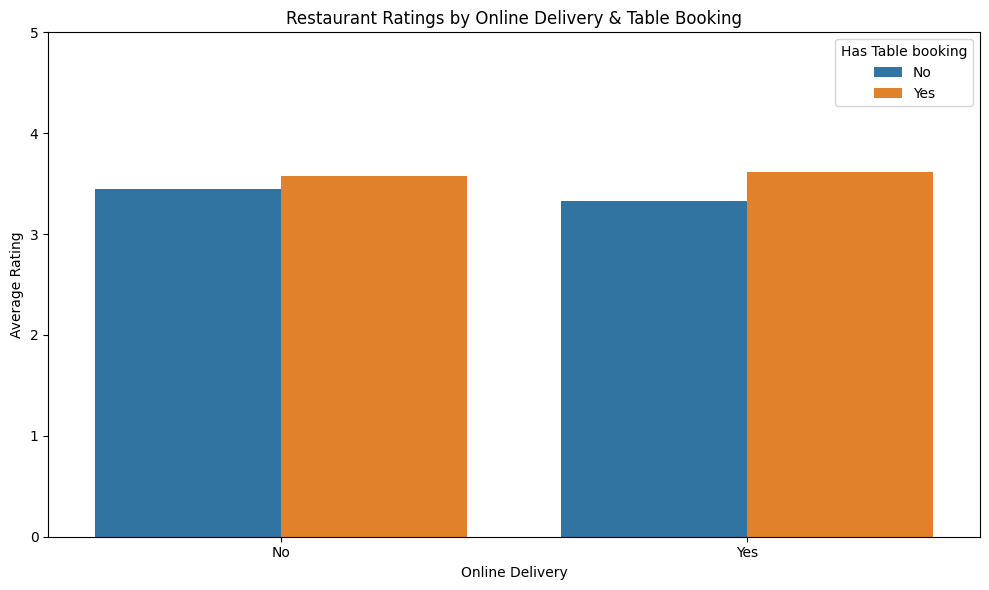

In [42]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=digital_rating,
    x="Has Online delivery",
    y="Average_Rating",
    hue="Has Table booking"
)

plt.title("Restaurant Ratings by Online Delivery & Table Booking")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [43]:

top_cities = (
    df_clean["City"]
    .value_counts()
    .head(15)
)

top_cities

City
New Delhi         5473
Gurgaon           1118
Noida             1080
Faridabad          251
Ghaziabad           25
Bhubaneshwar        21
Amritsar            21
Ahmedabad           21
Lucknow             21
Guwahati            21
Ludhiana            20
Rest of Hawaii      20
Kochi               20
Kolkata             20
Pocatello           20
Name: count, dtype: int64

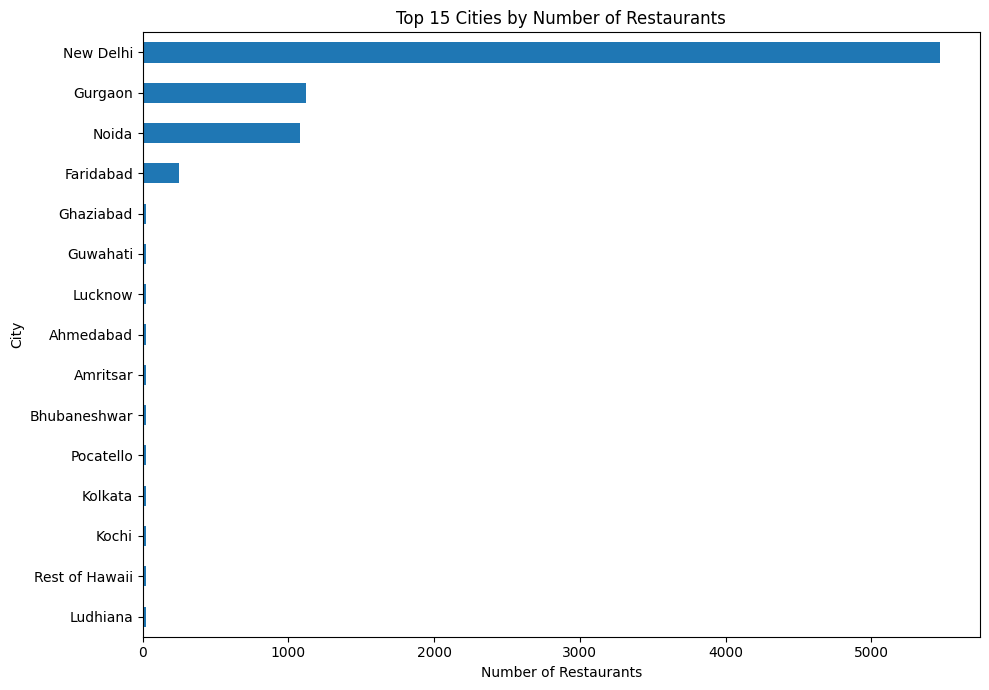

In [44]:
plt.figure(figsize=(10, 7))

top_cities.sort_values().plot(kind="barh")

plt.title("Top 15 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [45]:
city_performance = (
    df_rated
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Total_Votes=("Votes", "sum")
    )
    .reset_index()
)

city_performance_filtered = city_performance[
    city_performance["Restaurant_Count"] >= 30
].copy()

city_performance_filtered = (
    city_performance_filtered
    .sort_values("Average_Rating", ascending=False)
)

city_performance_filtered.head(15)

,City,Restaurant_Count,Average_Rating,Total_Votes
50,Gurgaon,890,3.330674,131978
88,New Delhi,4048,3.297381,627090
89,Noida,696,3.159626,73148
43,Faridabad,151,3.103311,6406


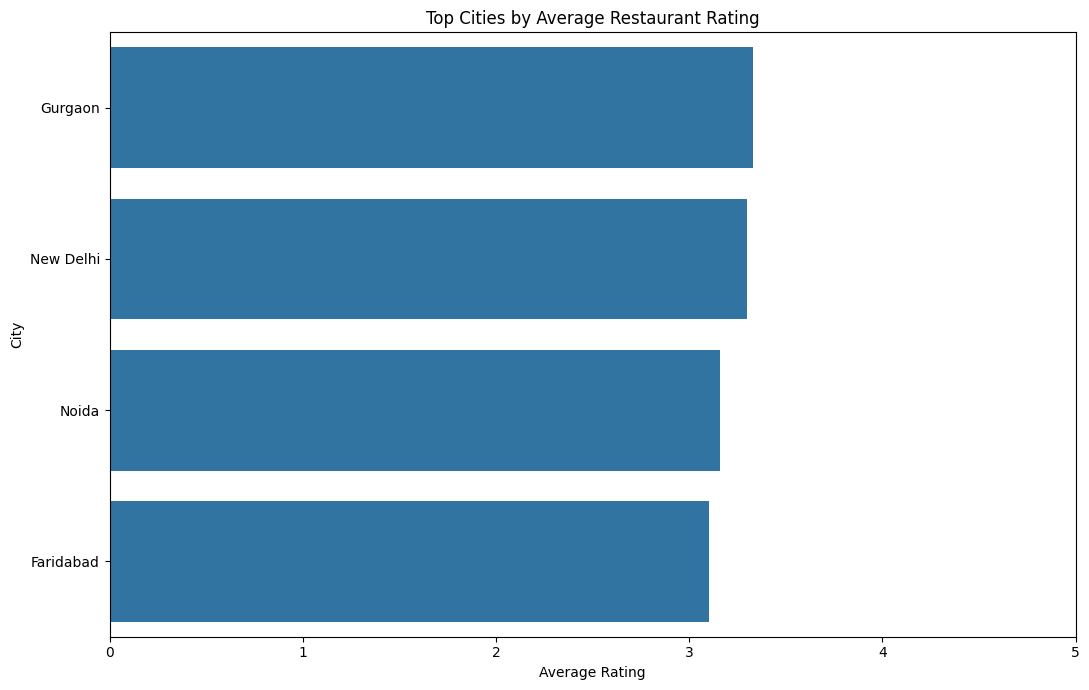

In [46]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=city_performance_filtered.head(15),
    x="Average_Rating",
    y="City"
)

plt.title("Top Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [47]:
top_10_city_count = (
    df_clean["City"]
    .value_counts()
    .head(10)
    .sum()
)

total_restaurants = len(df_clean)

percentage = (
    top_10_city_count / total_restaurants
) * 100

print(
    f"Top 10 cities contain {top_10_city_count:,} "
    f"restaurants ({percentage:.2f}% of the dataset)."
)

Top 10 cities contain 8,052 restaurants (84.31% of the dataset).


In [48]:

correlation_columns = [
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes"
]

correlation_matrix = df_rated[
    correlation_columns
].corr()

correlation_matrix

,Average Cost for two,Price range,Aggregate rating,Votes
Average Cost for two,1.000000,0.070531,0.076985,0.063381
Price range,0.070531,1.000000,0.403169,0.274103
Aggregate rating,0.076985,0.403169,1.000000,0.409018
Votes,0.063381,0.274103,0.409018,1.000000


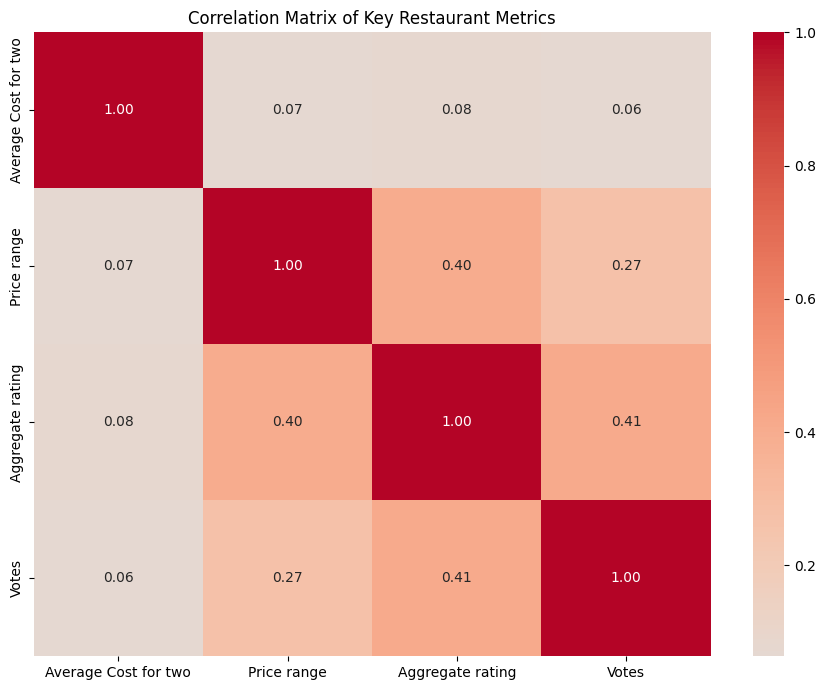

In [49]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Key Restaurant Metrics")

plt.tight_layout()
plt.show()

In [50]:

df_clean.to_csv("../data/restaurant_cleaned.csv", index=False)

df_rated.to_csv("../data/restaurant_rated.csv", index=False)

print("Cleaned datasets saved successfully!")

Cleaned datasets saved successfully!
